# Exploration - screening for cointegrated pairs

The cointegration test after regressing KO on PEP did not give enough evidence of cointegration.
Now, we'll explore over a larger set of stocks and try to find signals of possible cointegration among them.

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from itertools import combinations

In [5]:
sectors = {
    "Tech":        ["AAPL", "MSFT", "GOOGL", "META", "NVDA", "ORCL", "CSCO", "INTC"],
    "Financials":  ["JPM", "BAC", "WFC", "C", "GS", "MS"],
    "Healthcare":  ["JNJ", "PFE", "MRK", "ABT", "UNH", "LLY"],
    "Staples":     ["KO", "PEP", "PG", "CL", "WMT", "COST"],
    "Discretion.": ["AMZN", "HD", "LOW", "MCD", "NKE", "SBUX"],
    "Energy":      ["XOM", "CVX", "COP", "SLB"],
    "Industrials": ["CAT", "DE", "HON", "UPS", "FDX", "LMT"],
    "Utilities":   ["DUK", "SO", "NEE", "D"],
    "Comm.":       ["VZ", "CMCSA", "DIS"],
    "Materials":   ["APD", "SHW", "NEM"],
}

tickers = [t for group in sectors.values() for t in group]
sector_of = {t: s for s, group in sectors.items() for t in group}
print(len(tickers), "stocks")

52 stocks


In [6]:
prices = yf.download(tickers, start="2015-01-01", end="2025-01-01",
                     auto_adjust=True)["Close"]

missing = prices.columns[prices.isna().any()]
print("Dropping (missing data):", list(missing))
prices = prices.drop(columns=missing)[[t for t in tickers if t not in missing]]

logp = np.log(prices)
print(logp.shape)

[*********************100%***********************]  52 of 52 completed

Dropping (missing data): []
(2516, 52)


Now we test every pair:

In [7]:
cols = list(logp.columns)
pmat = pd.DataFrame(np.nan, index=cols, columns=cols)   # empty square table of p-values
rows = []

for a, b in combinations(cols, 2):
    _, p, _ = coint(logp[a], logp[b])   # we only keep the p-value
    pmat.loc[a, b] = p
    pmat.loc[b, a] = p
    rows.append((a, b, sector_of[a], sector_of[b], p))

results = (pd.DataFrame(rows, columns=["stock_a", "stock_b", "sector_a", "sector_b", "pvalue"])
             .sort_values("pvalue")
             .reset_index(drop=True))
print(f"{len(results)} pairs tested")

1326 pairs tested


We visualize with a heatmap:

In [1]:
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(pmat.values, cmap="viridis_r", vmin=0, vmax=0.2)
fig.colorbar(im, ax=ax, label="Engle–Granger p-value (capped at 0.2)")

ax.set_xticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols)))
ax.set_yticklabels(cols, fontsize=7)

# draw lines between sectors
boundaries = np.cumsum([sum(t in cols for t in g) for g in sectors.values()])[:-1]
for b in boundaries:
    ax.axhline(b - 0.5, color="white", linewidth=1)
    ax.axvline(b - 0.5, color="white", linewidth=1)

ax.set_title("Pairwise cointegration p-values (bright = more evidence of a pair)")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

A lot to unpack there. Let's plot all p-values (for all 1326 pairs) in a histogram:

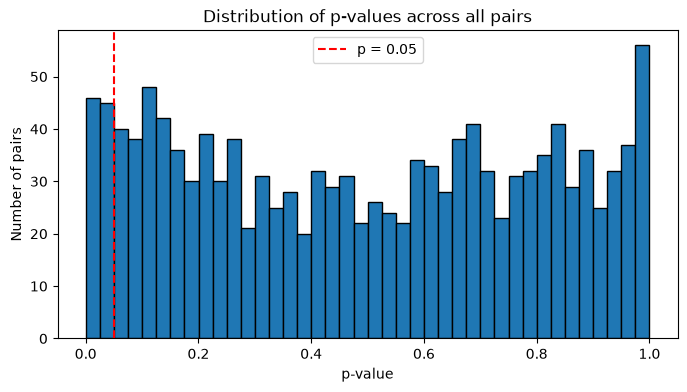

Pairs with p < 0.05: 91
Expected by chance alone if NO pair were real: about 66


In [9]:
plt.figure(figsize=(8, 4))
plt.hist(results["pvalue"], bins=40, edgecolor="black")
plt.axvline(0.05, color="red", linestyle="--", label="p = 0.05")
plt.xlabel("p-value")
plt.ylabel("Number of pairs")
plt.title("Distribution of p-values across all pairs")
plt.legend()
plt.show()

n = len(results)
print(f"Pairs with p < 0.05: {(results['pvalue'] < 0.05).sum()}")
print(f"Expected by chance alone if NO pair were real: about {0.05 * n:.0f}")

Note: If no pair were truly cointegrated, we would expect about 66 pairs (5% of all pairs tested)
to have p < 0.05 by chance alone. We found 91. The excess suggests that some of the signal
is real, but it is not conclusive: the tests are correlated (pairs share stocks), so the
count of false positives can vary more than a simple binomial model implies. We also cannot
conclude that exactly 25 pairs are real, nor tell which of the 91 flagged pairs they are.
The flagged pairs are candidates for further testing, such as out-of-sample validation.

Let's inspect the top candidates:

In [10]:
results.head(20)

,stock_a,stock_b,sector_a,sector_b,pvalue
0,HD,SHW,Discretion.,Materials,0.000194
1,KO,DUK,Staples,Utilities,0.000367
2,MSFT,HD,Tech,Discretion.,0.000666
3,AAPL,LOW,Tech,Discretion.,0.001032
4,HD,DUK,Discretion.,Utilities,0.001659
5,UNH,DUK,Healthcare,Utilities,0.001950
6,KO,SO,Staples,Utilities,0.002866
7,COST,SO,Staples,Utilities,0.003211
8,GOOGL,DUK,Tech,Utilities,0.003368
9,COST,DUK,Staples,Utilities,0.003846


Something intersting is going on here. We would expect the top cointegrated pairs to be stocks from the same industry, but that is not the case for the top 10 lowest p-values among those tested.

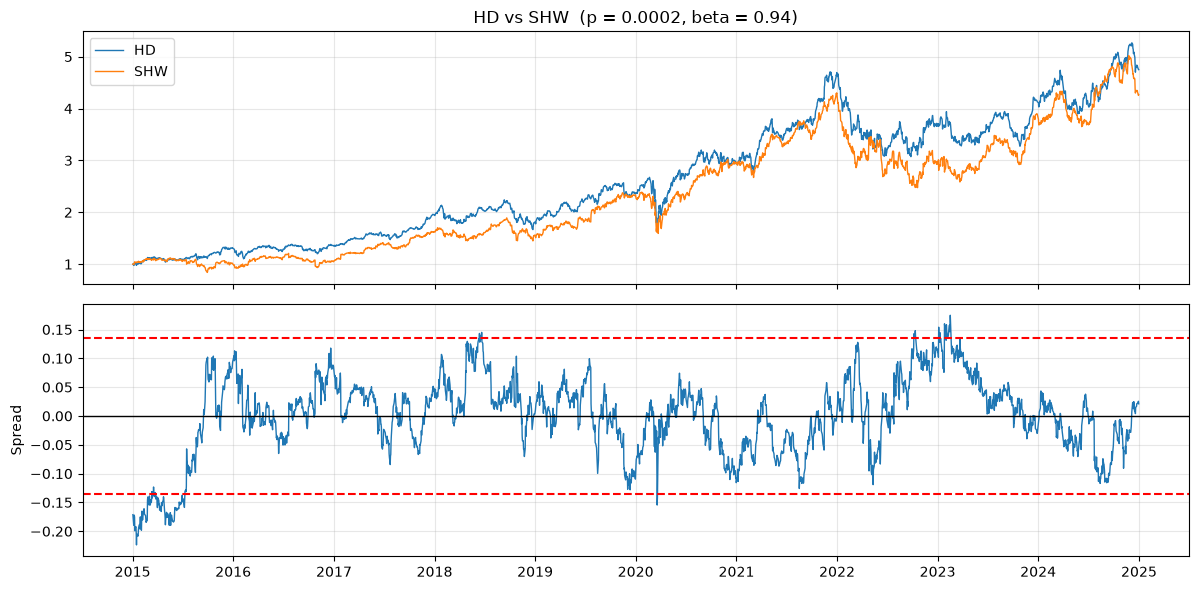

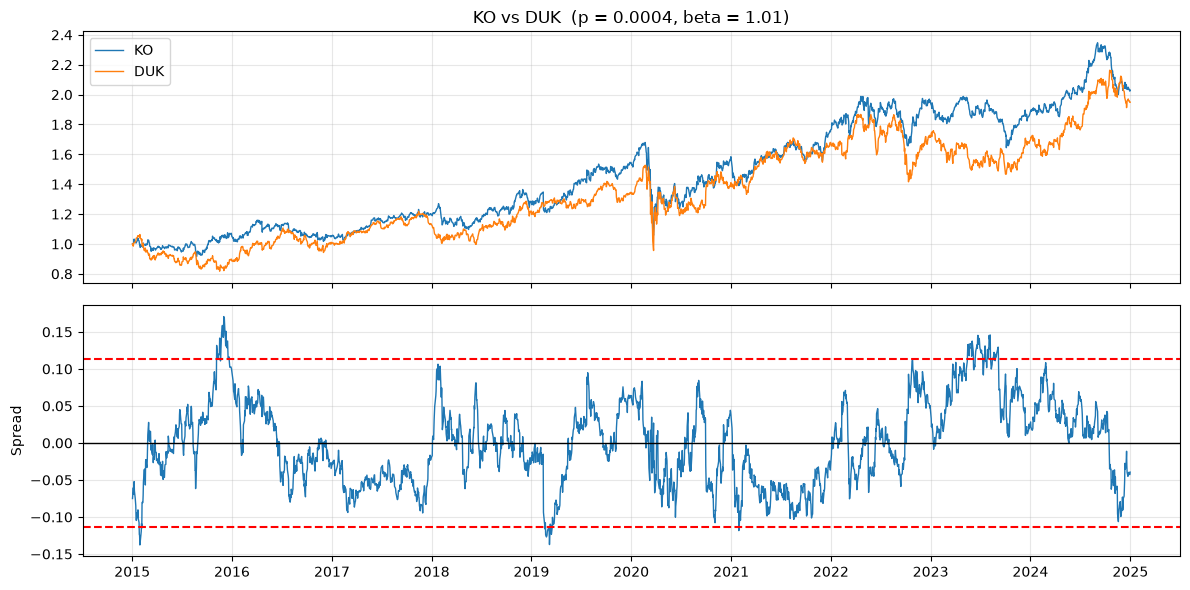

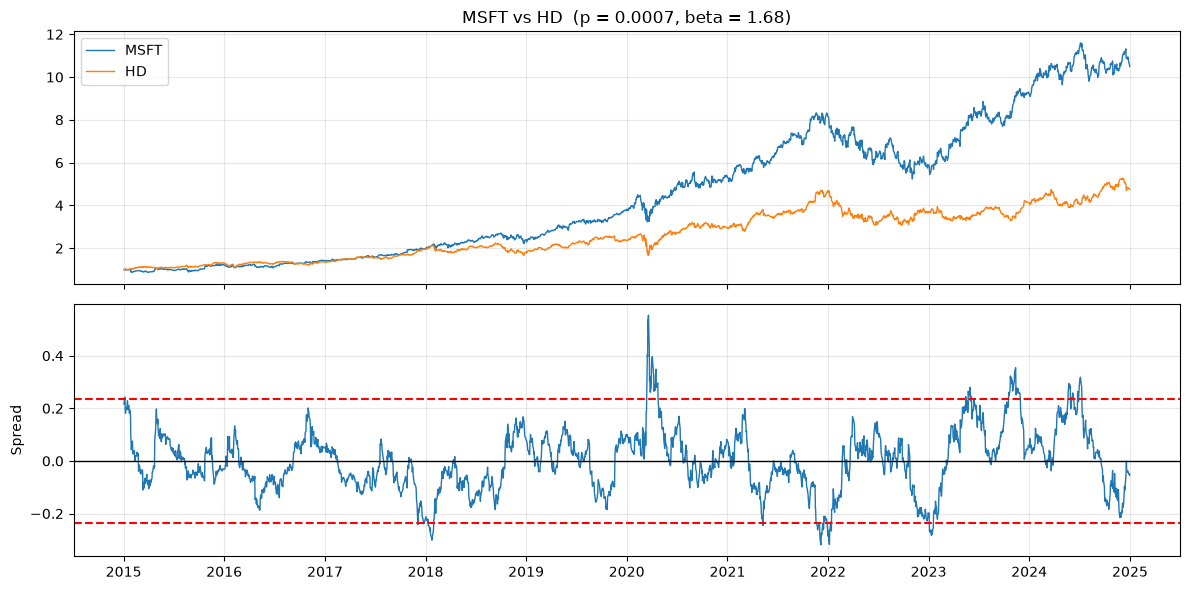

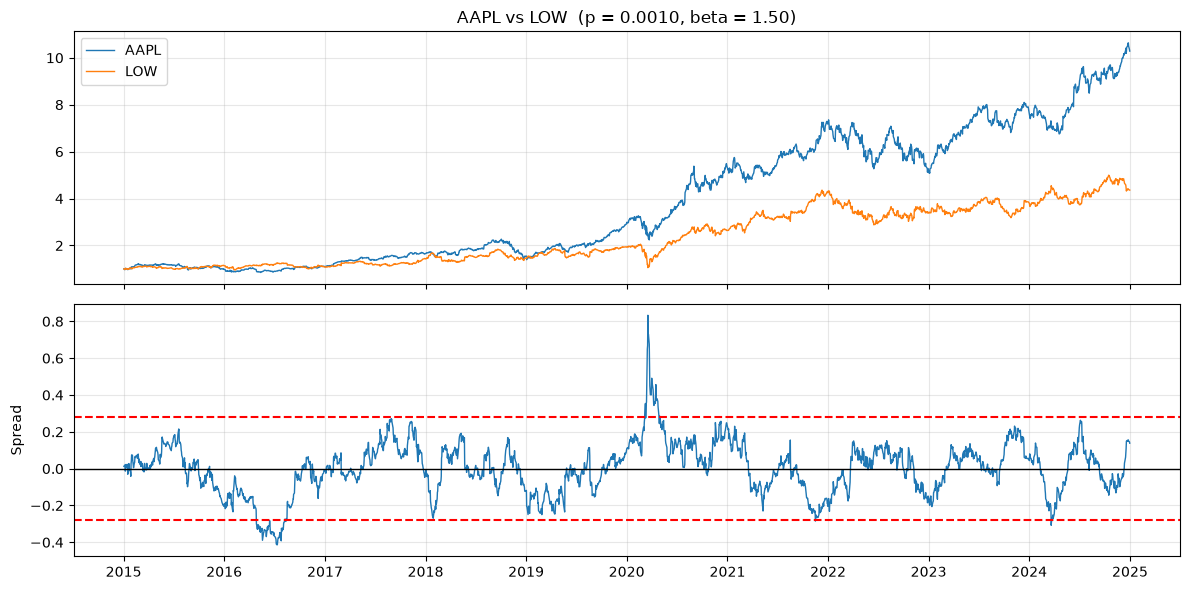

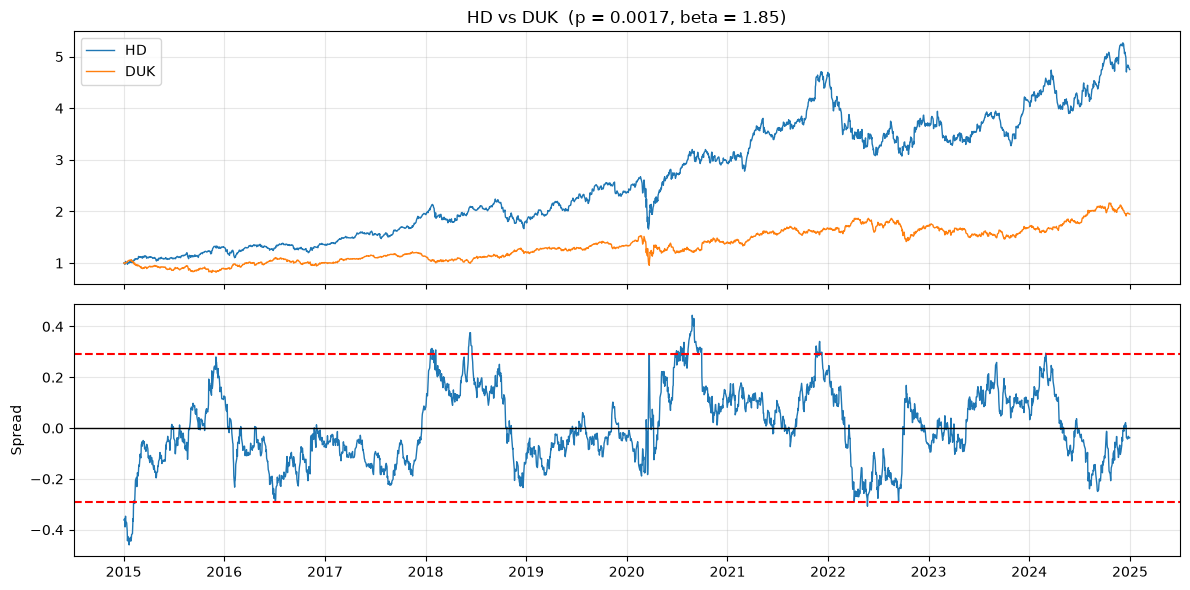

In [11]:
def plot_pair(a, b):
    x, y = logp[a], logp[b]
    model = sm.OLS(x, sm.add_constant(y)).fit()   # regression 1, as before
    spread = model.resid
    sd = spread.std()
    p = coint(x, y)[1]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    norm = prices[[a, b]] / prices[[a, b]].iloc[0]
    ax1.plot(norm.index, norm[a], label=a, linewidth=1)
    ax1.plot(norm.index, norm[b], label=b, linewidth=1)
    ax1.set_title(f"{a} vs {b}  (p = {p:.4f}, beta = {model.params.iloc[1]:.2f})")
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(spread.index, spread, linewidth=1)
    ax2.axhline(0, color="black", linewidth=1)
    ax2.axhline(2 * sd, color="red", linestyle="--")
    ax2.axhline(-2 * sd, color="red", linestyle="--")
    ax2.set_ylabel("Spread")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

for _, row in results.head(5).iterrows():
    plot_pair(row["stock_a"], row["stock_b"])

In [12]:
results[results[["stock_a", "stock_b"]].isin(["HD", "LOW", "SHW"]).all(axis=1)]

,stock_a,stock_b,sector_a,sector_b,pvalue
0,HD,SHW,Discretion.,Materials,0.000194
74,LOW,SHW,Discretion.,Materials,0.041013
266,HD,LOW,Discretion.,Discretion.,0.154472


Focusing on HD-SHW:

In [3]:
# 1. Look at it
plot_pair("HD", "SHW")

# 2. Test both directions (the regression direction matters)
print("HD on SHW:", coint(logp["HD"], logp["SHW"])[1])
print("SHW on HD:", coint(logp["SHW"], logp["HD"])[1])

# 3. The real test: does it hold in each half separately?
for start, end in [("2015-01-01", "2019-12-31"), ("2020-01-01", "2024-12-31")]:
    p = coint(logp.loc[start:end, "HD"], logp.loc[start:end, "SHW"])[1]
    print(f"{start[:4]}–{end[:4]}: p = {p:.4f}")

NameError: name 'plot_pair' is not defined

In [2]:
# spread from regression 1
model = sm.OLS(logp["HD"], sm.add_constant(logp["SHW"])).fit()
spread = model.resid

# AR(1): regress today's spread on yesterday's
ar_data = pd.DataFrame({"s": spread, "s_lag": spread.shift(1)}).dropna()
ar_model = sm.OLS(ar_data["s"], ar_data["s_lag"]).fit()
phi_hat = ar_model.params["s_lag"]

print(f"beta_hat  = {model.params['SHW']:.3f}")
print(f"phi_hat   = {phi_hat:.4f}")
print(f"half-life = {np.log(0.5) / np.log(phi_hat):.1f} trading days")

NameError: name 'sm' is not defined